<a href="https://colab.research.google.com/github/ahmed-zunaira/UTAT-Onboarding-Project/blob/main/UTAT_DL_Onboarding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing libraries
import numpy as np
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.metrics import r2_score

In [2]:
# loading the data
file_path = "/content/simpler_data_rwc.csv"
with open(file_path, 'r') as csvfile:
  data_reader = csv.reader(csvfile)

  data = []
  for row in data_reader:
    data.append(row)

data_np = np.array(data)
data_tensor = torch.from_numpy (data_np[1:,7:].astype(np.float32))
labels_tensor = torch.from_numpy (data_np[1:, 1:4].astype(np.float32))

# visualizing data
print (data_np[:, 1:4])
#print (data_tensor.shape)
#print (labels_tensor)


[['gv_fraction' 'npv_fraction' 'soil_fraction']
 ['0.0' '0.840237' '0.159763']
 ['0.0295858' '0.662722' '0.307692']
 ...
 ['0.331151' '0.668849' '0.0']
 ['0.405293' '0.594707' '0.0']
 ['0.467281' '0.532719' '0.0']]


In [3]:
# defining an MLP with two hidden layers
class MLP (nn.Module):
  def __init__ (self):
    super (MLP, self).__init__()
    self.layer1 = nn.Linear(210, 128)
    self.layer2 = nn.Linear (128, 128)
    self.layer3 = nn.Linear (128, 3)

  def forward(self, specs):
    activation1 = self.layer1(specs)
    activation1 = F.relu(activation1)
    activation2 = self.layer2(activation1)
    activation2 = F.relu(activation2)
    activation3 = self.layer3(activation2)
    return activation3

def plot_loss(epochs):
  val_loss = np.loadtxt("model_MLP_epoch{}_val_loss.csv".format(epochs))
  train_loss = np.loadtxt("model_MLP_epoch{}_train_loss.csv".format(epochs))

  plt.title("Train & Validation Loss")

  plt.plot (range(1, epochs+1), train_loss, label="Train")
  plt.plot (range(1, epochs+1), val_loss, label="Validation")

  plt.xlabel ("Epoch")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

def plot_r2 (data_type, epochs):
  r2_values = np.loadtxt("model_MLP_epoch{}_{}_r2.csv".format(epochs, data_type))

  plt.title ("Predicted vs. True Abundances: Validation (R-Squared)")

  plt.plot (range(1, epochs+1), r2_values)

  plt.xlabel ("Epoch")
  plt.ylabel("R-Squared Value")
  plt.show()

def plot_test ():
  true_values = np.loadtxt("model_MLP_test_output_true.csv")
  predicted_values = np.loadtxt("model_MLP_test_output_prediction.csv")

  plt.title ("Predicted vs. True Abundances: Testing")

  plt.scatter(true_values[:,0], predicted_values[:,0], color='green', label='GV')
  plt.scatter(true_values[:,1], predicted_values[:,1], color='red', label='NPV')
  plt.scatter(true_values[:,2], predicted_values[:,2], color='brown', label='Soil')

  min_val = np.min(true_values)
  max_val = np.max(true_values)
  plt.plot ([min_val, max_val], [min_val, max_val], linestyle='--')

  plt.legend(loc='best')

  plt.xlabel("True Abundance")
  plt.ylabel("Predicted Abundance")

  plt.show()

def test_MLP (net, data, labels):
  data_test = data[1464:]
  labels_test = labels[1464:]
  total_loss_test = 0.0
  model_outputs = []

  net.eval()

  criterion = nn.MSELoss()

  for i in range(len(data_test)):
    inputs = data_test[i]
    labels = labels_test[i]
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    loss_test = criterion (outputs, labels.float())

    total_loss_test += loss_test.item()

  model_outputs = np.array(model_outputs)
  r2 = r2_score (labels_test.detach().numpy(), model_outputs)
  loss = total_loss_test / (i+1)

  np.savetxt ("model_MLP_test_output_true.csv", labels_test)
  np.savetxt ("model_MLP_test_output_prediction.csv", model_outputs)

  return r2, loss


# evaluating the model on validation data
def evaluate_MLP (net, data, labels_val, criterion):
  total_loss_val = 0.0
  model_outputs = []

  net.eval()

  for i in range(len(data)):
    inputs = data[i]
    labels = labels_val[i]
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    loss_val = criterion (outputs, labels.float())

    total_loss_val += loss_val.item()

  r2 = r2_score (labels_val.detach().numpy(), np.array(model_outputs))
  loss = total_loss_val / (i+1)

  return r2, loss


# defining training function for model
def train_MLP (net, data_tensor, labels_tensor, num_epochs=30):
  # setting manual seed for replication
  torch.manual_seed(1)

  net.train()

  # splitting data
  data_train = data_tensor[0:1206] # 70%
  labels_train = labels_tensor[0:1206]

  data_val = data_tensor [1206:1464] # 15%
  labels_val = labels_tensor [1206:1464]

  # setting loss function and optimizer
  criterion = nn.MSELoss()
  optimizer = optim.AdamW(net.parameters())

  # setting up arrays to store losses over epochs
  train_loss = np.zeros(num_epochs)
  val_loss = np.zeros(num_epochs)
  val_r2 = np.zeros(num_epochs)

  start_time = time.time()

  for epoch in range(num_epochs):
    total_loss_train = 0.0

    for i in range(len(data_train)):
      inputs = data_train[i]
      labels = labels_train[i]

      optimizer.zero_grad()

      outputs = net(inputs)

      loss = criterion(outputs, labels.float())
      loss.backward()

      optimizer.step()

      total_loss_train += loss.item()

    train_loss[epoch] = float(total_loss_train) / (i+1)
    val_r2[epoch], val_loss[epoch] = evaluate_MLP (net, data_val, labels_val, criterion)
    print (("Epoch {}: Train loss: {}, Validation loss: {}, Validation r2: {}").format(epoch+1, train_loss[epoch], val_loss[epoch], val_r2[epoch]))
    torch.save(net.state_dict(), "model_MLP_epoch{}".format(epoch+1))

  print ("Training is complete.")
  end_time = time.time()
  total_time = end_time - start_time

  print ("Total time: {:.2f} seconds". format(total_time))

  # putting training & validation loss + loss r^2 values in files to plot after
  np.savetxt ("model_MLP_epoch{}_train_loss.csv".format(num_epochs), train_loss)
  np.savetxt ("model_MLP_epoch{}_val_loss.csv".format(num_epochs), val_loss)
  np.savetxt ("model_MLP_epoch{}_val_r2.csv".format(num_epochs), val_r2)


In [4]:
mlp = MLP()

train_MLP(mlp, data_tensor, labels_tensor, 100)

Epoch 1: Train loss: 0.05922647773405299, Validation loss: 0.0886969740670391, Validation r2: 0.14377884566783905
Epoch 2: Train loss: 0.0527572226493289, Validation loss: 0.08548393175989577, Validation r2: 0.15137381851673126
Epoch 3: Train loss: 0.0540226689705592, Validation loss: 0.06350073721368125, Validation r2: 0.38710179924964905
Epoch 4: Train loss: 0.05349356711135676, Validation loss: 0.08338923009957165, Validation r2: 0.18074412643909454
Epoch 5: Train loss: 0.05332171395523697, Validation loss: 0.0781428553849863, Validation r2: 0.2440371960401535
Epoch 6: Train loss: 0.04722669469531935, Validation loss: 0.14682850953808113, Validation r2: -0.3580961525440216
Epoch 7: Train loss: 0.04787218305308305, Validation loss: 0.08565748712896683, Validation r2: 0.1994558721780777
Epoch 8: Train loss: 0.05032099601634744, Validation loss: 0.07411346491166777, Validation r2: 0.28524067997932434
Epoch 9: Train loss: 0.051176759315057406, Validation loss: 0.06782517434447975, Valid

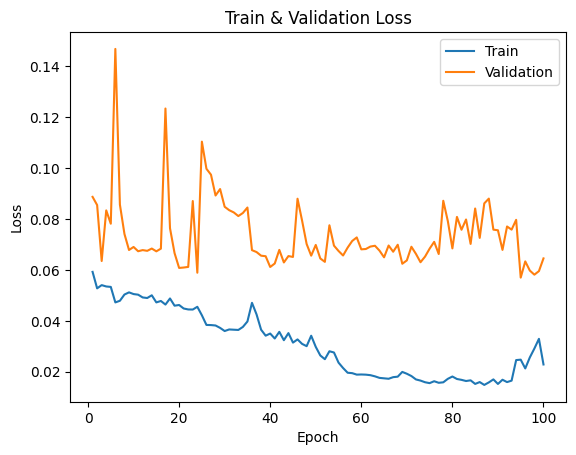

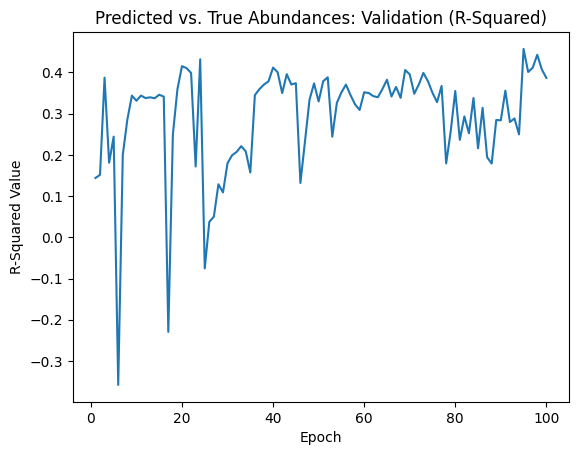

In [5]:
plot_loss(100)
plot_r2('val', 100)

R-Squared value of testing data: -0.1515762358903885


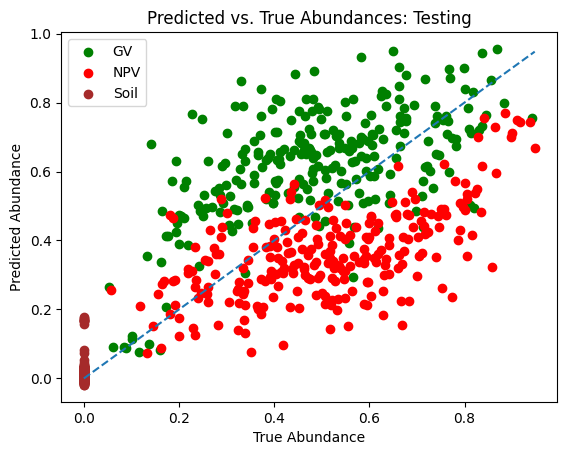

In [6]:
test_r2, test_loss = test_MLP(mlp, data_tensor, labels_tensor)

print ("R-Squared value of testing data:", test_r2)
plot_test()